In [1]:
from DatabankLib.protein_functions import *
import yaml

databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"


# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()

/home/sosamuli/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPsimBank/Data/Simulations


In [17]:
ID = 88

for system in systems:
    if system['ID'] == ID:
        dataFolder = '../../Data/Simulations/' + system['path']
        print(system['SYSTEM'])
        print(system['TRJ'])
        BMRBid = system['EXPERIMENT']['spin_relaxation']['path'][0]
        BMRBid = BMRBid.replace("BMRBid", "", 1)

#BMRBid = '50115'
spin_relaxation_time_file = dataFolder + 'spin_relaxation_times.yaml'

with open(spin_relaxation_time_file, "r") as file:
    spin_relaxation_times = yaml.safe_load(file)

try:
    exp_data_path = '../../Data/Experiments/spin_relaxation/BMRBid' + BMRBid
    experimental_spin_relaxation_times_file = exp_data_path + '/spin_relaxation_times.yaml'
    with open(experimental_spin_relaxation_times_file, 'r') as file:
        exp_spin_relaxation_times = yaml.safe_load(file)
except:
    exp_data_path = '../../Data/Experiments/spin_relaxation/' + BMRBid
    experimental_spin_relaxation_times_file = exp_data_path + '/spin_relaxation_times.yaml'
    with open(experimental_spin_relaxation_times_file, 'r') as file:
        exp_spin_relaxation_times = yaml.safe_load(file)

print(exp_data_path)


asyn
[['replica_05_CHARMM36M_md_2000ns.xtc']]
../../Data/Experiments/spin_relaxation/10.1074/jbc.m106777200


In [9]:
exp_spin_relaxation_times

{3: {'600.0': {'T1': {'error': '', 'value': 1.6630303030303029},
   'T2': {'error': '', 'value': 1.9340490797546013},
   'hetNOE': {'error': '', 'value': -0.324773413897281}}},
 4: {'600.0': {'hetNOE': {'error': '', 'value': -0.31208459214501516}}},
 5: {'600.0': {'T1': {'error': '', 'value': 1.561212121212121},
   'T2': {'error': '', 'value': 3.9079754601226995},
   'hetNOE': {'error': '', 'value': -0.028700906344410915}}},
 6: {'600.0': {'hetNOE': {'error': '', 'value': 0.1743202416918429}}},
 7: {'600.0': {'hetNOE': {'error': '', 'value': -0.1006042296072508}}},
 8: {'600.0': {'T1': {'error': '', 'value': 2.027878787878788},
   'T2': {'error': '', 'value': 3.1303680981595092},
   'hetNOE': {'error': '', 'value': 0.17009063444108763}}},
 9: {'600.0': {'T1': {'error': '', 'value': 1.6715151515151514},
   'T2': {'error': '', 'value': 3.8680981595092025},
   'hetNOE': {'error': '', 'value': -0.0033232628398791597}}},
 10: {'600.0': {'hetNOE': {'error': '', 'value': 0.3984894259818731}}}

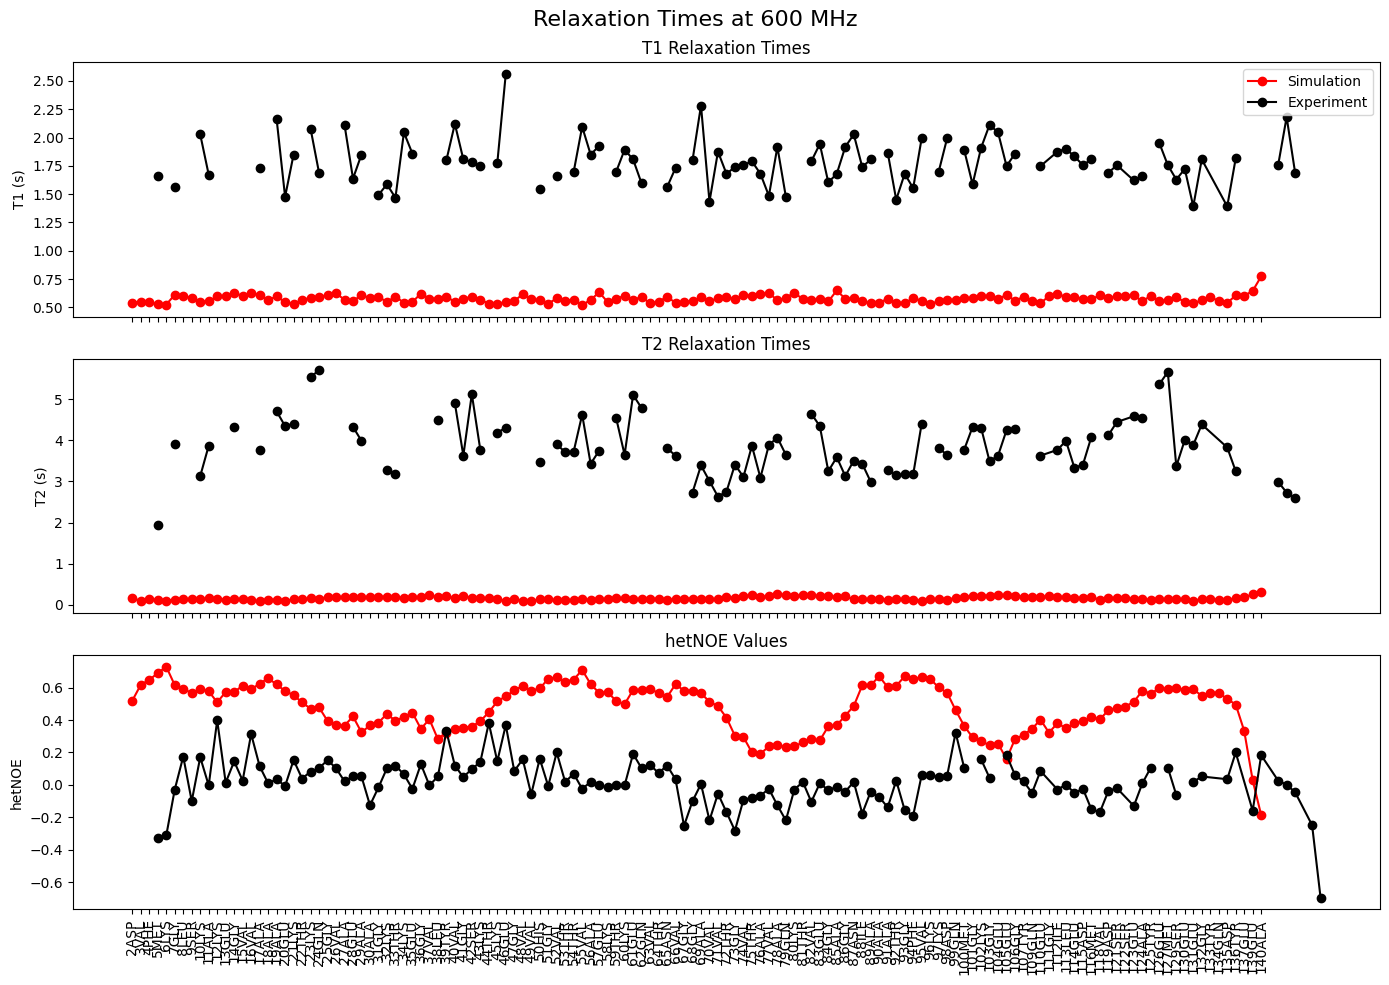

In [15]:
import matplotlib.pyplot as plt

# --- Load experimental data ---
exp_data = exp_spin_relaxation_times
sorted_exp = sorted(
    exp_data.items(),
    key=lambda x: int(''.join(filter(str.isdigit, str(x[0]))))
)
#sorted_exp = sorted(exp_data.items(), key=lambda x: int(''.join(filter(str.isdigit, x[0]))))
residues_exp = [
    res.replace('HIP', 'HIS') if isinstance(res, str) else res
    for res, _ in sorted_exp
]
#try:
##    residues_exp = [res.replace('HIP', 'HIS') for res, _ in sorted_exp]
##except:
#    residues_exp = [for res, _ in sorted_exp]

# Round fields in experimental data
rounded_data = []
for residue, field_dict in sorted_exp:
    new_field_dict = {}
    for field, values in field_dict.items():
        # round the second-level key
        #print(field)
        rounded_field = round(float(field))
        new_field_dict[rounded_field] = values
    rounded_data.append((residue, new_field_dict))

sorted_exp = rounded_data

exp_fields = set()
for _, vals in sorted_exp:
    exp_fields.update(vals.keys())
exp_fields = sorted(exp_fields)

#exp_fields = [round(x) for x in exp_fields]

# --- Load simulation data ---
sim_data = spin_relaxation_times
sorted_sim = sorted(sim_data.items(), key=lambda x: int(''.join(filter(str.isdigit, x[0]))))
residues_sim = [res.replace('HIP', 'HIS') for res, _ in sorted_sim]

sim_fields = set()
for _, vals in sorted_sim:
    sim_fields.update(vals.keys())
sim_fields = sorted(sim_fields)

# --- Common fields ---
field_strengths = sorted(set(sim_fields) & set(exp_fields))


# --- Plot per field ---
for field in field_strengths:
    # Experimental values
    T1_exp = [
        vals[field]['T1']['value'] if field in vals and 'T1' in vals[field] else float('nan')
        for _, vals in sorted_exp
    ]
    T2_exp = [
        vals[field]['T2']['value'] if field in vals and 'T2' in vals[field] else float('nan')
        for _, vals in sorted_exp
    ]
    hetNOE_exp = [
        vals[field]['hetNOE']['value'] if field in vals and 'hetNOE' in vals[field] else float('nan')
        for _, vals in sorted_exp
    ]

    # Simulation values
    T1_sim = [
        vals[field]['T1']['value'] if field in vals and 'T1' in vals[field] else float('nan')
        for _, vals in sorted_sim
    ]
    T2_sim = [
        vals[field]['T2']['value'] if field in vals and 'T2' in vals[field] else float('nan')
        for _, vals in sorted_sim
    ]
    hetNOE_sim = [
        vals[field]['hetNOE']['value'] if field in vals and 'hetNOE' in vals[field] else float('nan')
        for _, vals in sorted_sim
    ]

    # --- Plotting ---
    fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Relaxation Times at {field} MHz", fontsize=16)

    axs[0].plot(residues_sim, T1_sim, marker='o', color='red', label="Simulation")
    axs[0].plot(residues_exp, T1_exp, marker='o', color='black', label="Experiment")
    axs[0].set_ylabel('T1 (s)')
    axs[0].set_title('T1 Relaxation Times')
    axs[0].legend()

    axs[1].plot(residues_sim, T2_sim, marker='o', color='red', label="Simulation")
    axs[1].plot(residues_exp, T2_exp, marker='o', color='black', label="Experiment")
    axs[1].set_ylabel('T2 (s)')
    axs[1].set_title('T2 Relaxation Times')

    axs[2].plot(residues_sim, hetNOE_sim, marker='o', color='red', label="Simulation")
    axs[2].plot(residues_exp, hetNOE_exp, marker='o', color='black', label="Experiment")
    axs[2].set_ylabel('hetNOE')
    axs[2].set_title('hetNOE Values')
    axs[2].set_xticks(range(len(residues_sim)))
    axs[2].set_xticklabels(residues_sim, rotation=90)

    plt.tight_layout()
    plt.show()


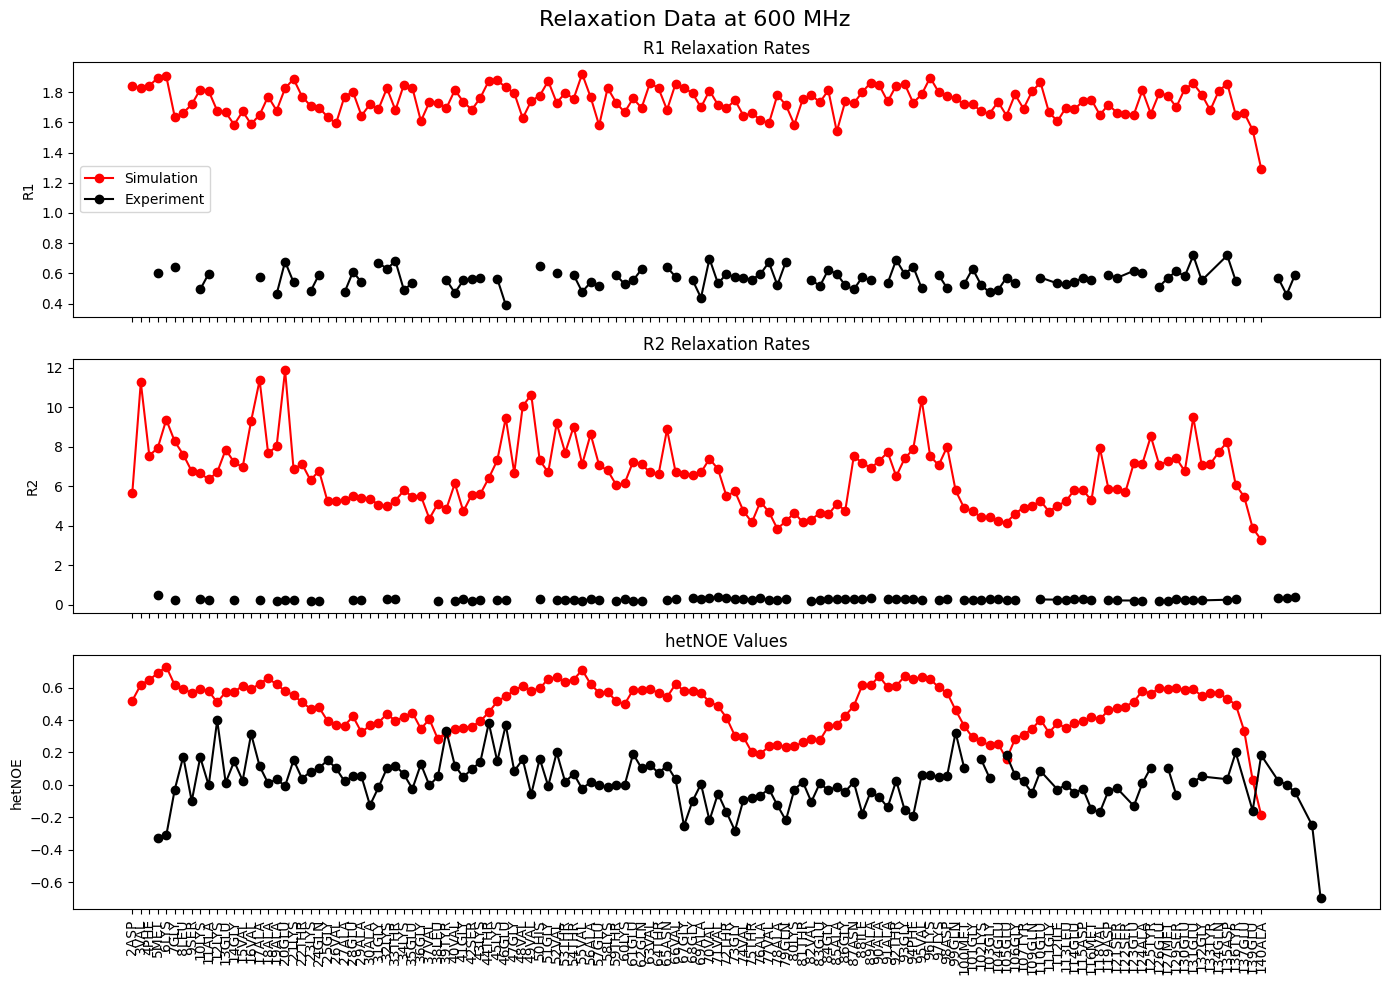

In [16]:
# Collect all field strengths in experimental data
exp_fields = set()
for _, vals in sorted_exp:
    exp_fields.update(vals.keys())
exp_fields = sorted(exp_fields)

# --- Load simulation data ---
sim_data = spin_relaxation_times

# Sort simulation data by residue index
sorted_sim = sorted(sim_data.items(), key=lambda x: int(''.join(filter(str.isdigit, x[0]))))
residues_sim = [res.replace('HIP', 'HIS') for res, _ in sorted_sim]

# Collect all field strengths in simulation data
sim_fields = set()
for _, vals in sorted_sim:
    sim_fields.update(vals.keys())
sim_fields = sorted(sim_fields)

# --- Use common field strengths (intersection) ---
field_strengths = sorted(set(sim_fields) & set(exp_fields))

# --- Plot per field ---
for field in field_strengths:
    # Experimental values
    T1_exp = [
        1 / vals[field]['T1']['value'] if field in vals and 'T1' in vals[field] else float('nan')
        for _, vals in sorted_exp
    ]
    T2_exp = [
        1 / vals[field]['T2']['value'] if field in vals and 'T2' in vals[field] else float('nan')
        for _, vals in sorted_exp
    ]
    hetNOE_exp = [
        vals[field]['hetNOE']['value'] if field in vals and 'hetNOE' in vals[field] else float('nan')
        for _, vals in sorted_exp
    ]

    # Simulation values
    T1_sim = [
        1 / vals[field]['T1']['value'] if field in vals and 'T1' in vals[field] else float('nan')
        for _, vals in sorted_sim
    ]
    T2_sim = [
        1 / vals[field]['T2']['value'] if field in vals and 'T2' in vals[field] else float('nan')
        for _, vals in sorted_sim
    ]
    hetNOE_sim = [
        vals[field]['hetNOE']['value'] if field in vals and 'hetNOE' in vals[field] else float('nan')
        for _, vals in sorted_sim
    ]

    # --- Plotting ---
    fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Relaxation Data at {field} MHz", fontsize=16)

    axs[0].plot(residues_sim, T1_sim, marker='o', color='red', label="Simulation")
    axs[0].plot(residues_exp, T1_exp, marker='o', color='black', label="Experiment")
    axs[0].set_ylabel('R1')
    axs[0].set_title('R1 Relaxation Rates')
    axs[0].legend()

    axs[1].plot(residues_sim, T2_sim, marker='o', color='red', label="Simulation")
    axs[1].plot(residues_exp, T2_exp, marker='o', color='black', label="Experiment")
    axs[1].set_ylabel('R2')
    axs[1].set_title('R2 Relaxation Rates')

    axs[2].plot(residues_sim, hetNOE_sim, marker='o', color='red', label="Simulation")
    axs[2].plot(residues_exp, hetNOE_exp, marker='o', color='black', label="Experiment")
    axs[2].set_ylabel('hetNOE')
    axs[2].set_title('hetNOE Values')
    axs[2].set_xticks(range(len(residues_sim)))
    axs[2].set_xticklabels(residues_sim, rotation=90)

    plt.tight_layout()
    plt.show()


In [22]:
# Sort data by numeric residue index
sorted_items = sorted(data.items(), key=lambda x: int(''.join(filter(str.isdigit, x[0]))))

# Extract residue names and inverse values
residues = [res for res, _ in sorted_items]
R1_values = [1.0 / vals['T1']['value'] if 'T1' in vals else float('nan') for _, vals in sorted_items]
R2_values = [1.0 / vals['T2']['value'] if 'T2' in vals else float('nan') for _, vals in sorted_items]
hetNOE_values = [vals['hetNOE']['value'] if 'hetNOE' in vals else float('nan') for _, vals in sorted_items]

# Plotting
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axs[0].plot(residues, R1_values, marker='o', color='blue')
axs[0].set_ylabel('R1 (1/s)')
axs[0].set_title('R1 Relaxation Rates (1/T1)')

axs[1].plot(residues, R2_values, marker='o', color='green')
axs[1].set_ylabel('R2 (1/s)')
axs[1].set_title('R2 Relaxation Rates (1/T2)')

axs[2].plot(residues, hetNOE_values, marker='o', color='red')
axs[2].set_ylabel('hetNOE')
axs[2].set_title('hetNOE Values')
axs[2].set_xticks(range(len(residues)))
axs[2].set_xticklabels(residues, rotation=90)

plt.tight_layout()
plt.show()


NameError: name 'data' is not defined

KeyError: 'T1'

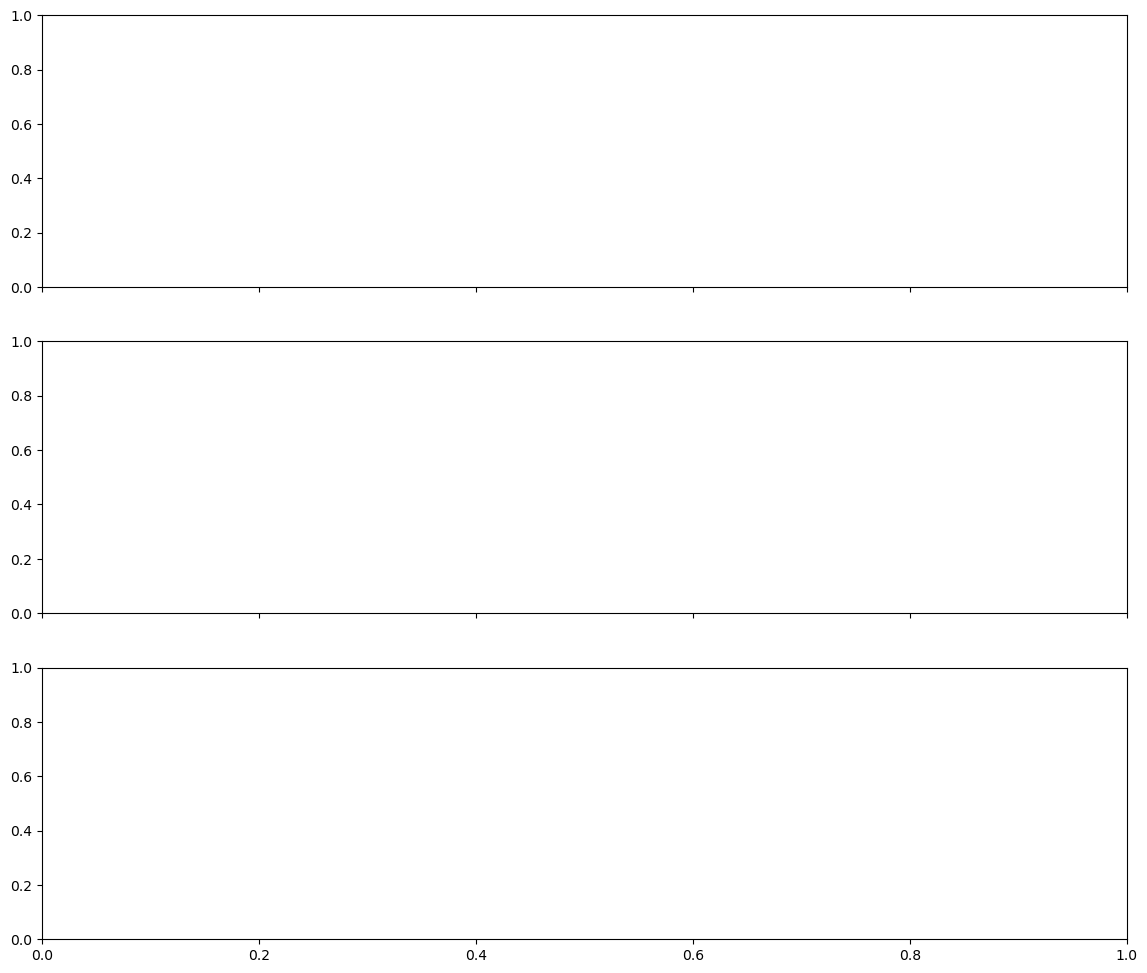

In [23]:
data = exp_spin_relaxation_times

# Function to extract data for plotting
def extract_data(field):
    residues = []
    values = []
    errors = []
    for res, val in data[field].items():
        residues.append(res)
        if field in ['T1', 'T2']:
            values.append(1 / val['value'])
            errors.append(val['error'] / (val['value'] ** 2))
        else:
            values.append(val['value'])
            errors.append(val['error'])
    return residues, values, errors

# Plotting
fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fields = ['T1', 'T2', 'hetNOE']
titles = ['1/T1 (s^-1)', '1/T2 (s^-1)', 'hetNOE']

for ax, field, title in zip(axs, fields, titles):
    residues, values, errors = extract_data(field)
    ax.errorbar(residues, values, yerr=errors, fmt='o', ecolor='gray', capsize=3, markersize=5)
    ax.set_ylabel(title)
    ax.grid(True)

axs[-1].set_xticks(range(len(residues)))
axs[-1].set_xticklabels(residues, rotation=90)
axs[-1].set_xlabel('Residue')
plt.tight_layout()
plt.show()



In [24]:
if my_dict.get('res') == 'HIP':
    my_dict['res'] = 'HIS'

NameError: name 'my_dict' is not defined

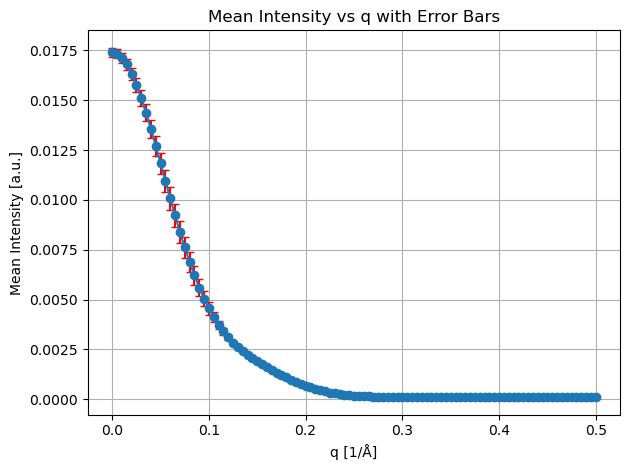

In [25]:
import matplotlib.pyplot as plt

# File path to your data
#filename = "/home/sosamuli/work/NMRlipids/IDPsimBank/Data/Simulations/bfe/5d3/bfe5d3fe2b5698dbf12e9d4d60f22a762bff44ac/f8712c6ebbc6f967e991909471d47a8668f36a23/SAXS.yaml"
#filename = "/home/sosamuli/work/NMRlipids/IDPsimBank/Data/Simulations/bfe/5d3/bfe5d3fe2b5698dbf12e9d4d60f22a762bff44ac/f8712c6ebbc6f967e991909471d47a8668f36a23/SAXS_MAICoS.yaml"

filename = "/home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations/a4a/b76/a4ab76000a75edec84067b72cc46ab9fc9664b8f/135a8efe6009486225f6c435892697a9da26c2db/SAXS.yaml"

# Initialize lists
q_values = []
mean_intensity = []
sd_intensity = []

# Read and parse the file
with open(filename, 'r') as f:
    lines = f.readlines()
    for i in range(0, len(lines), 3):
        q_line = lines[i].strip()
        mean_line = lines[i+1].strip()
        sd_line = lines[i+2].strip()
        
        q = float(q_line.split(":")[1])
        mean = float(mean_line.split(":")[1])
        sd = float(sd_line.split(":")[1])
        
        q_values.append(q)
        mean_intensity.append(mean)
        sd_intensity.append(sd)

# Plotting
plt.errorbar(q_values, mean_intensity, yerr=sd_intensity, fmt='o-', ecolor='red', capsize=3)
plt.xlabel("q [1/Å]")
plt.ylabel("Mean Intensity [a.u.]")
plt.title("Mean Intensity vs q with Error Bars")
plt.grid(True)
plt.tight_layout()
plt.show()

q_values_crysol = q_values
mean_intensity_crysol = mean_intensity
sd_intensity_crysol = sd_intensity


In [20]:
import matplotlib.pyplot as plt

# File path to your data
#filename = "/home/sosamuli/work/NMRlipids/IDPsimBank/Data/Simulations/bfe/5d3/bfe5d3fe2b5698dbf12e9d4d60f22a762bff44ac/f8712c6ebbc6f967e991909471d47a8668f36a23/SAXS.yaml"
#filename = "/home/sosamuli/work/NMRlipids/IDPsimBank/Data/Simulations/bfe/5d3/bfe5d3fe2b5698dbf12e9d4d60f22a762bff44ac/f8712c6ebbc6f967e991909471d47a8668f36a23/SAXS_MAICoS.yaml"

filename = "/home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations/a4a/b76/a4ab76000a75edec84067b72cc46ab9fc9664b8f/135a8efe6009486225f6c435892697a9da26c2db/SAXS_MAICoS_noWater.yaml"

# Initialize lists
q_values = []
mean_intensity = []
#sd_intensity = []

# Read and parse the file
with open(filename, 'r') as f:
    lines = f.readlines()
    for i in range(0, len(lines), 2):
        q_line = lines[i].strip()
        mean_line = lines[i+1].strip()
        #sd_line = lines[i+2].strip()
        
        q = float(q_line.split(":")[1])
        mean = float(mean_line.split(":")[1])
        #sd = float(sd_line.split(":")[1])
        
        q_values.append(q)
        mean_intensity.append(mean)
        #sd_intensity.append(sd)

# Plotting
#plt.errorbar(q_values, mean_intensity, yerr=sd_intensity, fmt='o-', ecolor='red', capsize=3)
constant = 1000000-300000
mean_intensity_scaled =  [x * constant for x in mean_intensity_crysol]
    

plt.errorbar(q_values_crysol, mean_intensity_scaled, yerr=sd_intensity_crysol, fmt='o-', ecolor='red', capsize=3, markersize=10, label = "Crysol")
plt.errorbar(q_values, mean_intensity, fmt='o-', ecolor='red', capsize=3, label = "MAICoS")
plt.xlabel("q [1/Å]")
plt.ylabel("Mean Intensity [a.u.]")
plt.title("Mean Intensity vs q with Error Bars")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()



q_values_MAICoS_nowater = q_values
mean_intensity_MAICoS_nowater = mean_intensity
sd_intensity_MAICoS_nowater = sd_intensity


FileNotFoundError: [Errno 2] No such file or directory: '/home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations/a4a/b76/a4ab76000a75edec84067b72cc46ab9fc9664b8f/135a8efe6009486225f6c435892697a9da26c2db/SAXS_MAICoS_noWater.yaml'

NameError: name 'q_values_MAICoS_nowater' is not defined

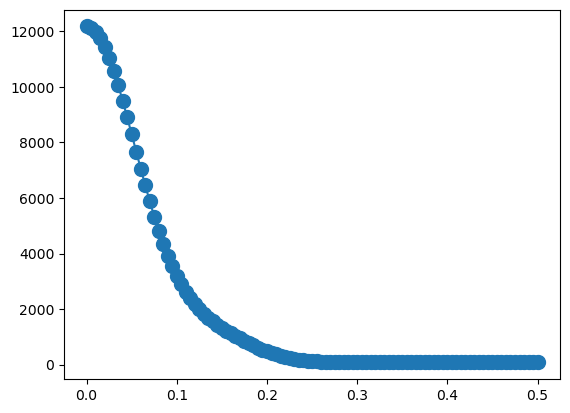

In [21]:
import matplotlib.pyplot as plt

# File path to your data
#filename = "/home/sosamuli/work/NMRlipids/IDPsimBank/Data/Simulations/bfe/5d3/bfe5d3fe2b5698dbf12e9d4d60f22a762bff44ac/f8712c6ebbc6f967e991909471d47a8668f36a23/SAXS.yaml"
#filename = "/home/sosamuli/work/NMRlipids/IDPsimBank/Data/Simulations/bfe/5d3/bfe5d3fe2b5698dbf12e9d4d60f22a762bff44ac/f8712c6ebbc6f967e991909471d47a8668f36a23/SAXS_MAICoS.yaml"

filename = "/home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations/a4a/b76/a4ab76000a75edec84067b72cc46ab9fc9664b8f/135a8efe6009486225f6c435892697a9da26c2db/SAXS_MAICoS.yaml"

# Initialize lists
q_values = []
mean_intensity = []
#sd_intensity = []

# Read and parse the file
with open(filename, 'r') as f:
    lines = f.readlines()
    for i in range(0, len(lines), 2):
        q_line = lines[i].strip()
        mean_line = lines[i+1].strip()
        #sd_line = lines[i+2].strip()
        
        q = float(q_line.split(":")[1])
        mean = float(mean_line.split(":")[1])
        #sd = float(sd_line.split(":")[1])
        
        q_values.append(q)
        mean_intensity.append(mean)
        #sd_intensity.append(sd)

# Plotting
#plt.errorbar(q_values, mean_intensity, yerr=sd_intensity, fmt='o-', ecolor='red', capsize=3)
constant = 1000000-300000
mean_intensity_scaled =  [x * constant for x in mean_intensity_crysol]
    

plt.errorbar(q_values_crysol, mean_intensity_scaled, yerr=sd_intensity_crysol, fmt='o-', ecolor='red', capsize=3, markersize=10, label = "Crysol")
plt.errorbar(q_values_MAICoS_nowater, mean_intensity_MAICoS_nowater, fmt='o-', ecolor='red', capsize=3, label = "MAICoS nowater")
plt.errorbar(q_values, mean_intensity, fmt='o-', ecolor='red', capsize=3, label = "MAICoS")
plt.xlabel("q [1/Å]")
plt.ylabel("Mean Intensity [a.u.]")
plt.title("Mean Intensity vs q with Error Bars")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


## Plotting chemical shifts

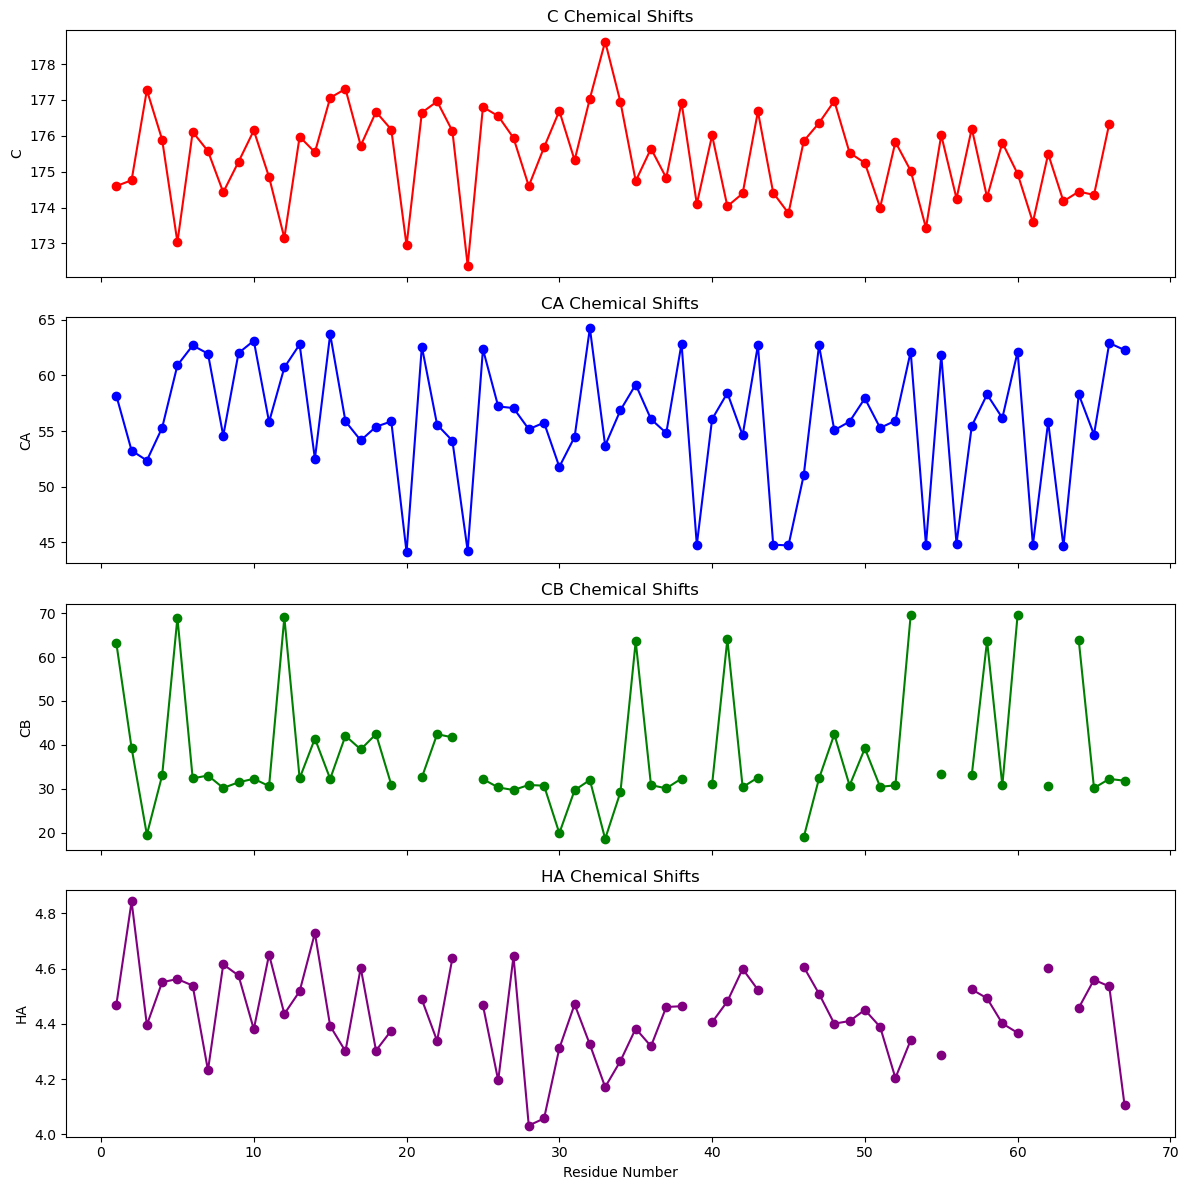

In [22]:
# Example input data (you can replace this with reading from YAML or JSON if needed)

chemical_shifts_file = dataFolder + 'chemical_shifts_sparta.yaml'

with open(chemical_shifts_file, "r") as file:
    data = yaml.safe_load(file)
    

# Extract residue numbers
residues = sorted(data.keys())

# Extract values for each nucleus of interest
C_values = [data[res].get("C", float("nan")) for res in residues]
CA_values = [data[res].get("CA", float("nan")) for res in residues]
CB_values = [data[res].get("CB", float("nan")) for res in residues]
HA_values = [data[res].get("HA", float("nan")) for res in residues]

# Plotting
fig, axs = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axs[0].plot(residues, C_values, marker='o', color='red')
axs[0].set_ylabel("C")
axs[0].set_title("C Chemical Shifts")

axs[1].plot(residues, CA_values, marker='o', color='blue')
axs[1].set_ylabel("CA")
axs[1].set_title("CA Chemical Shifts")

axs[2].plot(residues, CB_values, marker='o', color='green')
axs[2].set_ylabel("CB")
axs[2].set_title("CB Chemical Shifts")

axs[3].plot(residues, HA_values, marker='o', color='purple')
axs[3].set_ylabel("HA")
axs[3].set_title("HA Chemical Shifts")
axs[3].set_xlabel("Residue Number")

plt.tight_layout()
plt.show()
